# Dirac-3S QPLIB Benchmarking with qci_client

In [ ]:
import qci_client as qc
import numpy as np
import time
import os
import matplotlib.pyplot as plt
client = qc.QciClient(api_token="<API_TOKEN>", url="https://api.qci-prod.com")


### Set up dirac-3S solver

In [17]:
def convert_hamiltonian_to_poly_format(linear_terms, quadratic_terms, tol=0.0):
    """
    Convert (c, Q) of H(x) = x^T Q x + c^T x into Dirac-3 polynomial format.
    """
    c = np.asarray(linear_terms, dtype=float).ravel()
    Q = np.asarray(quadratic_terms, dtype=float)
    n = c.shape[0]

    if Q.shape != (n, n):
        raise ValueError(f"quadratic_terms has shape {Q.shape}, expected ({n}, {n})")

    poly_indices = []
    poly_coefficients = []

    # Linear terms
    for i in range(n):
        if abs(c[i]) > tol:
            poly_indices.append([0, i + 1])
            poly_coefficients.append(float(c[i]))

    # Quadratic terms -- fold the lower triangle onto the upper triangle
    Q_upper = np.triu(Q) + np.tril(Q, -1).T
    for i in range(n):
        for j in range(i, n):
            val = Q_upper[i, j]
            if abs(val) > tol:
                poly_indices.append([i + 1, j + 1])
                poly_coefficients.append(float(val))

    return poly_indices, poly_coefficients

def solve_dirac3(num_var, indices, coefficients, relaxation_schedule=1, sum_constraint=100, num_samples=1, device='dirac-3S'):
    data = [{"idx":idx, "val":val} for idx, val in zip(indices, coefficients)]
    file_quadratic = {
        "file_name": "dirac_3_continuous_variable_example",
        "file_config": {
            "polynomial": {
                "num_variables": num_var,
                "min_degree": 1,
                "max_degree": 2,
                "data": data,
            }
        }
    }
    # upload to qci client
    file_response = client.upload_file(file=file_quadratic)
    job_body = client.build_job_body(
        job_type = 'sample-hamiltonian',
        job_name = 'planted_quadratic', # user-defined (optional)
        job_params = {
            'device_type': device,
            'relaxation_schedule':relaxation_schedule,
            'sum_constraint':sum_constraint,
            'num_samples':num_samples,
        },
        polynomial_file_id=file_response['file_id'],
    )

    job_response = client.process_job(job_body=job_body)
    get_job_metrics_response = client.get_job_metrics(job_id=job_response["job_info"]["job_id"])
    return job_response, get_job_metrics_response

### load instance function

In [18]:
def read_qplib(path):
    with open(path) as fh:
        toks = [t for t in (line.split("#")[0].strip() for line in fh) if t]

    pos = 0

    def nxt():
        nonlocal pos
        val = toks[pos]
        pos += 1
        return val

    def defaulted(length):
        """Read a `default value` / `number of non-defaults` / entries block."""
        arr = np.full(length, float(nxt()))
        for _ in range(int(nxt())):
            i, v = nxt().split()
            arr[int(i) - 1] = float(v)
        return arr

    name = nxt()
    probtype = nxt()
    sense = nxt().lower()
    n = int(nxt())
    m = int(nxt())

    # quadratic terms of the objective (each unordered pair listed once)
    Q = np.zeros((n, n), dtype=np.float32)
    for _ in range(int(nxt())):
        i, j, v = nxt().split()
        i, j, v = int(i) - 1, int(j) - 1, float(v)
        if i == j:
            Q[i, i] = v
        else:
            Q[i, j] = Q[j, i] = 0.5 * v   # split the pair coefficient over both triangles

    b = defaulted(n)            # linear terms of the objective
    obj_const = float(nxt())

    # linear terms of the constraints
    A = np.zeros((m, n))
    for _ in range(int(nxt())):
        k, i, v = nxt().split()
        A[int(k) - 1, int(i) - 1] = float(v)

    inf = float(nxt())
    lhs, rhs = defaulted(m), defaulted(m)
    lb, ub = defaulted(n), defaulted(n)

    return dict(name=name, type=probtype, sense=sense, n=n, m=m,
                Q=Q, b=b, obj_const=obj_const,
                A=A, lhs=lhs, rhs=rhs, lb=lb, ub=ub, inf=inf)


### solve using dirac-3S

In [19]:
inst_dir = "Instances/"
inst_name = "QPLIB_0018.qplib"
inst = read_qplib(os.path.join(inst_dir, inst_name))
n, Q, b = inst["n"], inst["Q"], inst["b"]
M = 0.5 * Q
c = b.copy()

poly_indices, poly_coefficients = convert_hamiltonian_to_poly_format(
    linear_terms=c,
    quadratic_terms=M.copy(), 
)

In [20]:
def objective(x):
    x = np.asarray(x, dtype=float)
    return float(x @ M @ x + c @ x) + inst["obj_const"]

sum_constraint = float(inst["rhs"][0])   # sum_i x_i = 1
relaxation_schedule = 2
num_samples = 100

device = 'dirac-3s'


poly_indices, poly_coefficients = convert_hamiltonian_to_poly_format(
                    linear_terms=c,
                    quadratic_terms=M.copy(),   # the util mutates its input
                )

response, metrics = solve_dirac3(
                        num_var=n,
                        indices=poly_indices,
                        coefficients=poly_coefficients,
                        relaxation_schedule=relaxation_schedule,
                        sum_constraint=sum_constraint,
                        device=device,
                        num_samples=num_samples)
print(f"Dirac-3 Run complete. Response received.")
metrics = metrics["job_metrics"]
time_ns = metrics["time_ns"]
device = time_ns["device"][f"{device}"] #f"{device}"
runtimes = device["samples"]["runtime"]
pre = device["samples"].get("preprocessing_time", 0)
post = device["samples"]["postprocessing_time"]
solutions = response["results"]["solutions"]
energies = response['results']['energies']

runtimes_sec = [t*1e-9 for t in runtimes]
post_sec  = [t*1e-9 for t in post]

print(f"Dirac-3 all samples energies:{[round(e, 2) for e in energies]}")
print(f"Dirac-3 all samples runtimes:{[round(t, 2) for t in runtimes]}")



2026-10-06 08:18:26 - Dirac allocation balance = 0 s (unmetered)
2026-10-06 08:18:26 - Job submitted: job_id='6ac4e712358b23d0cb3719ec'
2026-10-06 08:18:26 - QUEUED
2026-10-06 08:18:29 - RUNNING
2026-10-06 08:20:51 - COMPLETED
2026-10-06 08:20:54 - Dirac allocation balance = 0 s (unmetered)
Dirac-3 Run complete. Response received.
Dirac-3 all samples energies:[-6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.39, -6.06, -6.06, -5.99, -5.98, -5.98, -5.89, -5.87, -5.87, -5.87, -5.85, -5.85, -5.84, -5.82, -5.82, -5.82, -5.82, -5.82, -5.82, -5.82, -5.82, -5.82, -5.82, -5.82, -5.82, -5.82, -5.81, -5.81, -5.76, -5.75, -5.69, -5.41]
Dirac-3 all samples runtimes:[1054423690, 1616972446, 1552427888, 1545442820, 1637048006, 1711126566, 1060212731, 1084016204, 2153601170, 1734755993, 1671967626, 143861

In [21]:
best = min(zip(energies, solutions, runtimes_sec, post_sec), key=lambda x: x[0])
dirac_energy, best_solution, best_runtime, best_postprocessing_time = best
preprocessing_time = pre*1e-9


print(f"Eenergy value obtained by Dirac-3:{dirac_energy}")
print(f"Solution sum:{sum(best_solution)} (target {sum_constraint}), support:{np.count_nonzero(best_solution)}")
print(f"Preprocessing Time:{preprocessing_time}")
print(f"Time taken for this run:{best_runtime}")
print(f"Postprocessing Time for this run:{best_postprocessing_time}")

Eenergy value obtained by Dirac-3:-6.3860159
Solution sum:1.0 (target 1.0), support:4
Preprocessing Time:0.0052235450000000004
Time taken for this run:1.0544236900000001
Postprocessing Time for this run:5.253e-05


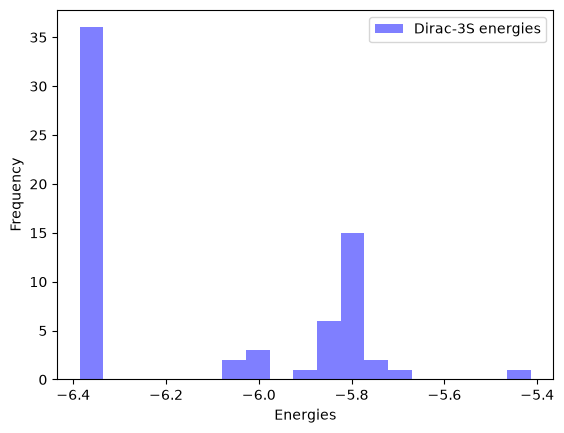

In [22]:
dirac_energies = np.array(energies)


lo = min(dirac_energies)
hi = max(dirac_energies)
bins = np.linspace(lo, hi, 20)


plt.hist(dirac_energies, bins=bins, color="blue", alpha=0.5,
         label="Dirac-3S energies")


plt.xlabel("Energies")
plt.ylabel("Frequency")
plt.legend()
plt.show()